In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging

from itertools import product
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    from pmdarima import auto_arima
except Exception:
    auto_arima = None

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").disabled = True

In [30]:
def load_partner_data(path: str) -> pd.DataFrame:
    """
    Загружает статистику партнера за 2 года
    """
    partner_data = pd.read_excel(path)

    partner_data = partner_data.rename(
        columns={
            "Дата": "month",
            "Клиенты": "clients",
            "Чеки": "transactions",
            "Оборот": "revenue",
            "Средний чек": "avg_check",
            "Чатсота покупок": "purchase_frequency "
        }
    )

    partner_data["month"] = pd.to_datetime(partner_data["month"]).dt.to_period("M").dt.to_timestamp()
    partner_data = partner_data.sort_values("month").reset_index(drop=True)

    return partner_data

In [31]:
df = load_partner_data("Статистика 2024-2025.xlsx")
df

,month,clients,transactions,revenue,avg_check,purchase_frequency
0,2024-01-01,21608,75670,48315445.25,638.501986,3.50
1,2024-02-01,21463,74368,49804689.76,669.705919,3.46
2,2024-03-01,22734,82479,54938213.85,666.087293,3.63
3,2024-04-01,22226,80113,51943617.83,648.379387,3.60
4,2024-05-01,22888,84450,54541795.13,645.847189,3.69
5,2024-06-01,22258,82536,52897637.59,640.903819,3.71
6,2024-07-01,22639,85077,53266477.76,626.097274,3.76
7,2024-08-01,22238,83452,51101946.47,612.351369,3.75
8,2024-09-01,21865,80225,49782617.46,620.537457,3.67
9,2024-10-01,22417,84790,53908353.24,635.786688,3.78


In [ ]:
def load_seasonality(path: str, category: str) -> pd.DataFrame:
    """
    Загружает коэффициенты сезонности по категории
    """
    seasonality_data = pd.read_excel(path)

    seasonality_data = seasonality_data.rename(
        columns={
            "Категория": "category",
            "мес": "month_num",
            "Клиенты": "coef_clients",
            "Средний чек": "coef_avg_check",
            "Чеки": "coef_transactions",
        }
    )

    seasonality_data = seasonality_data[seasonality_data["category"] == category]
    seasonality_data.set_index("month_num")

    return seasonality_data

### Список категорий:
''Авто и запчасти'', ''Аптеки'', ''Детские товары'', ''Заправки'', ''Здоровье'', ''Зоотовары'', ''Интернет-магазины'', ''Кафе и рестораны'', ''Косметика и парфюмерия'', ''Мебель и товары для дома'', ''Обувь'', ''Одежда'', ''Продукты'', ''Развлечения для детей'', ''Спорт'', ''Страхование'', ''Такси'', ''Товары для ремонта'', ''Электроника'', ''Ювелирные изделия'', ''Путешествия''

In [32]:
season = load_seasonality("Сезонность.xlsx", "Продукты")
season

,category,month_num,coef_clients,coef_avg_check,coef_transactions
144,Продукты,1,0.953991,1.089423,0.991947
145,Продукты,2,0.986680,1.088919,0.974323
146,Продукты,3,1.024853,1.071610,1.051354
147,Продукты,4,1.022519,1.010094,1.041118
148,Продукты,5,1.023909,0.997952,1.059944
149,Продукты,6,0.997307,0.961929,1.017961
150,Продукты,7,0.986685,0.945670,1.005670
151,Продукты,8,0.983091,0.934958,0.984916
152,Продукты,9,0.964722,0.926719,0.954551
153,Продукты,10,0.990471,0.926660,0.974638


In [ ]:
def robust_outlier_mask(series: pd.Series, window: int = 3, z_threshold: float = 3.5) -> pd.Series:
    rolling_median = series.rolling(window=window, center=True, min_periods=1).median()
    abs_deviation = (series - rolling_median).abs()
    rolling_mad = abs_deviation.rolling(window=window, center=True, min_periods=1).median()

    robust_z_score = 0.6745 * (series - rolling_median) / rolling_mad.replace(0, np.nan)
    return robust_z_score.abs() > z_threshold


def clean_partner_data(
    partner_data: pd.DataFrame,
    columns_to_clean=("clients", "transactions", "avg_check", "revenue"),
    freq="MS",
):
    cleaned_data = partner_data.copy().sort_values("month")
    cleaned_data = cleaned_data.set_index("month").asfreq(freq)

    cleaning_report = {}

    for column_name in columns_to_clean:
        if column_name not in cleaned_data.columns:
            continue

        series = pd.to_numeric(cleaned_data[column_name], errors="coerce")
        series = series.replace([np.inf, -np.inf], np.nan)

        if column_name in {"clients", "transactions", "avg_check", "revenue"}:
            series = series.mask(series < 0)

        outlier_mask = robust_outlier_mask(series)
        series = series.mask(outlier_mask)

        missing_or_outlier_mask = series.isna()

        series = series.interpolate(method="time", limit_direction="both")
        series = series.ffill().bfill()

        cleaned_data[column_name] = series

        cleaning_report[column_name] = pd.DataFrame(
            {
                "month": cleaned_data.index,
                "was_missing_or_outlier": missing_or_outlier_mask.astype(int),
                "clean_value": series,
            }
        )

    return cleaned_data.reset_index(), cleaning_report

In [ ]:
df, cleaning_report = clean_partner_data(df)
df

,month,clients,transactions,revenue,avg_check,purchase_frequency
0,2024-01-01,21608,75670.000000,4.831545e+07,638.501986,3.50
1,2024-02-01,21463,74368.000000,4.980469e+07,669.705919,3.46
2,2024-03-01,22734,82479.000000,5.493821e+07,666.087293,3.63
3,2024-04-01,22226,80113.000000,5.194362e+07,648.379387,3.60
4,2024-05-01,22888,84450.000000,5.454180e+07,645.847189,3.69
5,2024-06-01,22258,82536.000000,5.289764e+07,640.903819,3.71
6,2024-07-01,22639,85077.000000,5.326648e+07,626.097274,3.76
7,2024-08-01,22238,83452.000000,5.110195e+07,612.351369,3.75
8,2024-09-01,21865,80225.000000,4.978262e+07,620.537457,3.67
9,2024-10-01,22417,84790.000000,5.390835e+07,635.786688,3.78


In [ ]:
#cleaning_report

In [ ]:
def calculate_metrics(y_true, y_pred):
    non_zero_mask = y_true != 0
    mape = (
        np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
        if non_zero_mask.any()
        else np.nan
    )

    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mape": mape,
    }

In [ ]:
def prepare_metric_data(df, season, metric_column, seasonality_column):
    prophet_df = df[["month", metric_column]].rename(columns={"month": "ds", metric_column: "y"})
    sarimax_df = df[["month", metric_column]].set_index("month").asfreq("MS")

    prophet_df = prophet_df.merge(
        season[["month_num", seasonality_column]],
        left_on=prophet_df["ds"].dt.month,
        right_on="month_num",
        how="left",
    ).drop(columns=["month_num"])

    if prophet_df[seasonality_column].isna().any():
        raise ValueError(f"Не удалось подтянуть сезонность для {metric_column}")

    return prophet_df, sarimax_df

In [ ]:
def fit_prophet_model(train_df, seasonality_column, changepoint_prior_scale, seasonality_prior_scale):
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale,
        interval_width=0.95,
    )
    model.add_regressor(seasonality_column)
    model.fit(train_df)
    return model

In [ ]:
def build_time_series_folds(data_length, min_train_size=12, horizon=3):
    # адаптация под короткие ряды
    if data_length < 18:
        min_train_size = max(6, data_length - 3)
        horizon = min(2, max(1, data_length - min_train_size))

    folds = []

    for test_start in range(min_train_size, data_length - horizon + 1):
        train_slice = slice(0, test_start)
        test_slice = slice(test_start, test_start + horizon)
        folds.append((train_slice, test_slice))

    if len(folds) > 3:
        return folds[-3:]
    return folds

In [ ]:
def tune_prophet_params(
    prophet_df,
    seasonality_column,
    changepoint_scales,
    seasonality_scales,
    min_train_size=12,
    horizon=3,
):
    folds = build_time_series_folds(
        data_length=len(prophet_df),
        min_train_size=min_train_size,
        horizon=horizon,
    )

    # если ряд слишком короткий и фолды не строятся -- возвращаем дефолт
    if len(folds) == 0:
        return {
            "changepoint_prior_scale": 0.05,
            "seasonality_prior_scale": 10.0,
        }

    best_params = None
    best_mae = np.inf

    for cps in changepoint_scales:
        for sps in seasonality_scales:
            fold_maes = []

            for train_slice, test_slice in folds:
                train_fold = prophet_df.iloc[train_slice].copy()
                test_fold = prophet_df.iloc[test_slice].copy()

                try:
                    model = fit_prophet_model(
                        train_df=train_fold,
                        seasonality_column=seasonality_column,
                        changepoint_prior_scale=cps,
                        seasonality_prior_scale=sps,
                    )
                    forecast = model.predict(test_fold[["ds", seasonality_column]])
                    fold_maes.append(mean_absolute_error(test_fold["y"], forecast["yhat"]))
                except Exception:
                    continue

            if len(fold_maes) == 0:
                continue

            mean_mae = np.mean(fold_maes)

            if mean_mae < best_mae:
                best_mae = mean_mae
                best_params = {
                    "changepoint_prior_scale": cps,
                    "seasonality_prior_scale": sps,
                }

    if best_params is None:
        best_params = {
            "changepoint_prior_scale": 0.05,
            "seasonality_prior_scale": 10.0,
        }

    return best_params

In [ ]:
def tune_sarimax_params(train_series, p_values, d_values, q_values, P_values, D_values, Q_values, trend_values):
    best_params = None
    best_aic = np.inf

    if auto_arima is not None:
        try:
            auto_model = auto_arima(
                train_series,
                seasonal=True,
                m=12,
                start_p=min(p_values),
                max_p=max(p_values),
                start_q=min(q_values),
                max_q=max(q_values),
                start_P=min(P_values),
                max_P=max(P_values),
                start_Q=min(Q_values),
                max_Q=max(Q_values),
                start_d=min(d_values),
                max_d=max(d_values),
                start_D=min(D_values),
                max_D=max(D_values),
                information_criterion="aic",
                error_action="ignore",
                suppress_warnings=True,
                stepwise=True,
                trace=False,
            )

            start_order = auto_model.order
            start_seasonal_order = auto_model.seasonal_order

            p_values_local = sorted(set([start_order[0] - 1, start_order[0], start_order[0] + 1]) & set(p_values))
            d_values_local = [start_order[1]] if start_order[1] in d_values else d_values
            q_values_local = sorted(set([start_order[2] - 1, start_order[2], start_order[2] + 1]) & set(q_values))

            P_values_local = sorted(set([start_seasonal_order[0] - 1, start_seasonal_order[0], start_seasonal_order[0] + 1]) & set(P_values))
            D_values_local = [start_seasonal_order[1]] if start_seasonal_order[1] in D_values else D_values
            Q_values_local = sorted(set([start_seasonal_order[2] - 1, start_seasonal_order[2], start_seasonal_order[2] + 1]) & set(Q_values))

            if not p_values_local:
                p_values_local = p_values
            if not q_values_local:
                q_values_local = q_values
            if not P_values_local:
                P_values_local = P_values
            if not Q_values_local:
                Q_values_local = Q_values
        except Exception:
            p_values_local = p_values
            d_values_local = d_values
            q_values_local = q_values
            P_values_local = P_values
            D_values_local = D_values
            Q_values_local = Q_values
    else:
        p_values_local = p_values
        d_values_local = d_values
        q_values_local = q_values
        P_values_local = P_values
        D_values_local = D_values
        Q_values_local = Q_values

    for order in product(p_values_local, d_values_local, q_values_local):
        for seasonal_values in product(P_values_local, D_values_local, Q_values_local):
            seasonal_order = (seasonal_values[0], seasonal_values[1], seasonal_values[2], 12)

            for trend in trend_values:
                try:
                    model = SARIMAX(
                        train_series,
                        order=order,
                        seasonal_order=seasonal_order,
                        trend=trend,
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    )
                    results = model.fit(disp=False, maxiter=200)

                    if results.aic < best_aic:
                        best_aic = results.aic
                        best_params = {
                            "order": order,
                            "seasonal_order": seasonal_order,
                            "trend": trend,
                            "aic": results.aic,
                        }
                except Exception:
                    continue

    return best_params

In [ ]:
def fit_sarimax_model(train_series, best_params):
    model = SARIMAX(
        train_series,
        order=best_params["order"],
        seasonal_order=best_params["seasonal_order"],
        trend=best_params["trend"],
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    results = model.fit(disp=False)
    return results

In [ ]:
def select_best_ensemble_weight(y_true, yhat_prophet, yhat_sarimax, candidate_weights):
    best_weight = 0.5
    best_mae = np.inf

    for w_prophet in candidate_weights:
        w_sarimax = 1 - w_prophet
        ensemble_pred = w_prophet * yhat_prophet + w_sarimax * yhat_sarimax
        mae = mean_absolute_error(y_true, ensemble_pred)

        if mae < best_mae:
            best_mae = mae
            best_weight = w_prophet

    return best_weight

In [ ]:
metric_settings = {
    "clients": {
        "display_name": "Клиенты",
        "seasonality_column": "coef_clients",
        "round_digits": 0,
        "clip_lower": 0,
        "prophet_changepoint_scales": [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5],
        "prophet_seasonality_scales": [1.0, 5.0, 10.0],
        "sarimax_p": [0, 1, 2, 3],
        "sarimax_d": [0, 1],
        "sarimax_q": [0, 1, 2, 3],
        "sarimax_P": [0, 1, 2],
        "sarimax_D": [0, 1],
        "sarimax_Q": [0, 1, 2],
        "sarimax_trend": ["n", "c", "t"],
        "ensemble_weights": [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    },
    "avg_check": {
        "display_name": "Средний чек",
        "seasonality_column": "coef_avg_check",
        "round_digits": 2,
        "clip_lower": 0,
        "prophet_changepoint_scales": [0.005, 0.01, 0.03, 0.05, 0.1, 0.2],
        "prophet_seasonality_scales": [1.0, 3.0, 5.0, 10.0],
        "sarimax_p": [0, 1, 2, 3],
        "sarimax_d": [0, 1, 2],
        "sarimax_q": [0, 1, 2, 3],
        "sarimax_P": [0, 1, 2],
        "sarimax_D": [0, 1],
        "sarimax_Q": [0, 1, 2],
        "sarimax_trend": ["n", "c", "t"],
        "ensemble_weights": [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    },
    "transactions": {
        "display_name": "Чеки",
        "seasonality_column": "coef_transactions",
        "round_digits": 0,
        "clip_lower": 0,
        "prophet_changepoint_scales": [0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
        "prophet_seasonality_scales": [1.0, 5.0, 10.0],
        "sarimax_p": [0, 1, 2, 3],
        "sarimax_d": [0, 1],
        "sarimax_q": [0, 1, 2, 3],
        "sarimax_P": [0, 1, 2],
        "sarimax_D": [0, 1],
        "sarimax_Q": [0, 1, 2],
        "sarimax_trend": ["n", "c", "t"],
        "ensemble_weights": [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    },
}

In [ ]:
all_metric_results = {}
forecast_tables_2026 = {}

In [36]:
logging.getLogger("prophet").disabled = True


# ----------- КЛИЕНТЫ -----------
Размер train: 19
Размер test: 5

### Prophet
Лучшие параметры Prophet: {'changepoint_prior_scale': 0.2, 'seasonality_prior_scale': 1.0}

### SARIMAX
Лучшие параметры SARIMAX: {'order': (3, 0, 0), 'seasonal_order': (0, 1, 0, 12), 'trend': 'c', 'aic': np.float64(-51.85443365878014)}
Сошлась ли модель SARIMAX?: False

### Ансамбль
Лучший вес Prophet: 0.2
Лучший вес SARIMAX: 0.8
Метрики на тесте:
prophet {'mae': 1427.431437823055, 'rmse': np.float64(1505.9429331517945), 'mape': np.float64(5.889461358697576)}
sarimax {'mae': 582.7975344083941, 'rmse': np.float64(741.3274058909049), 'mape': np.float64(2.3929663924358753)}
ensemble {'mae': 699.5257163312381, 'rmse': np.float64(864.6679835571609), 'mape': np.float64(2.875682676422674)}


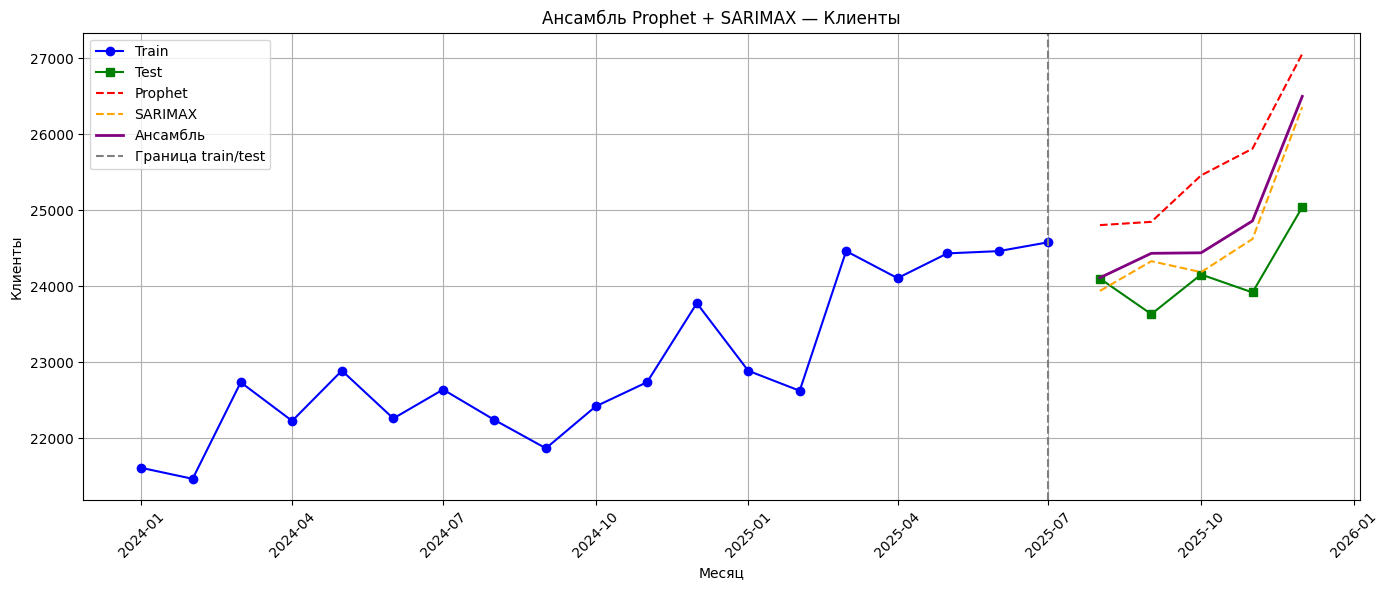


### Строим прогноз на год

Сошлась ли модель SARIMAX?: True


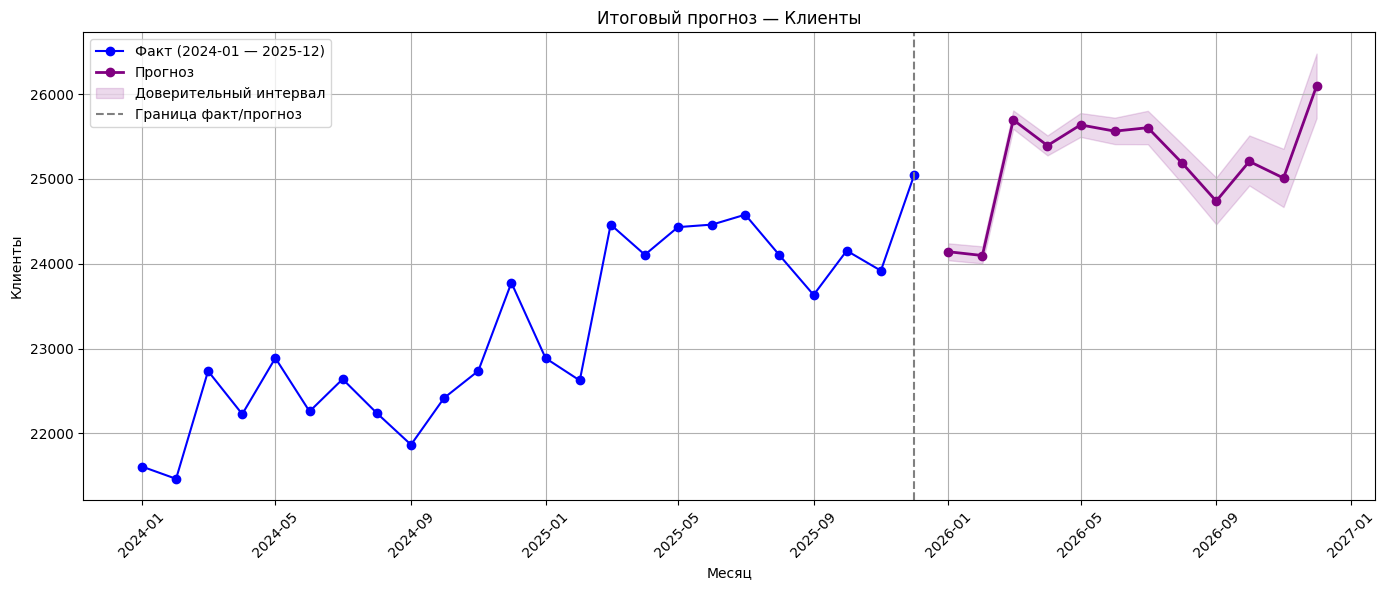


# ----------- СРЕДНИЙ ЧЕК -----------
Размер train: 19
Размер test: 5

### Prophet
Лучшие параметры Prophet: {'changepoint_prior_scale': 0.005, 'seasonality_prior_scale': 1.0}

### SARIMAX
Лучшие параметры SARIMAX: {'order': (3, 0, 0), 'seasonal_order': (0, 1, 0, 12), 'trend': 'c', 'aic': np.float64(-66.67642371598083)}
Сошлась ли модель SARIMAX?: False

### Ансамбль
Лучший вес Prophet: 0.8
Лучший вес SARIMAX: 0.2
Метрики на тесте:
prophet {'mae': 28.875686844935945, 'rmse': np.float64(31.103396959832605), 'mape': np.float64(4.147098376941584)}
sarimax {'mae': 40.88577298267542, 'rmse': np.float64(46.158548026593735), 'mape': np.float64(5.794414855739549)}
ensemble {'mae': 30.185852672145437, 'rmse': np.float64(32.32115500511164), 'mape': np.float64(4.3433301103875515)}


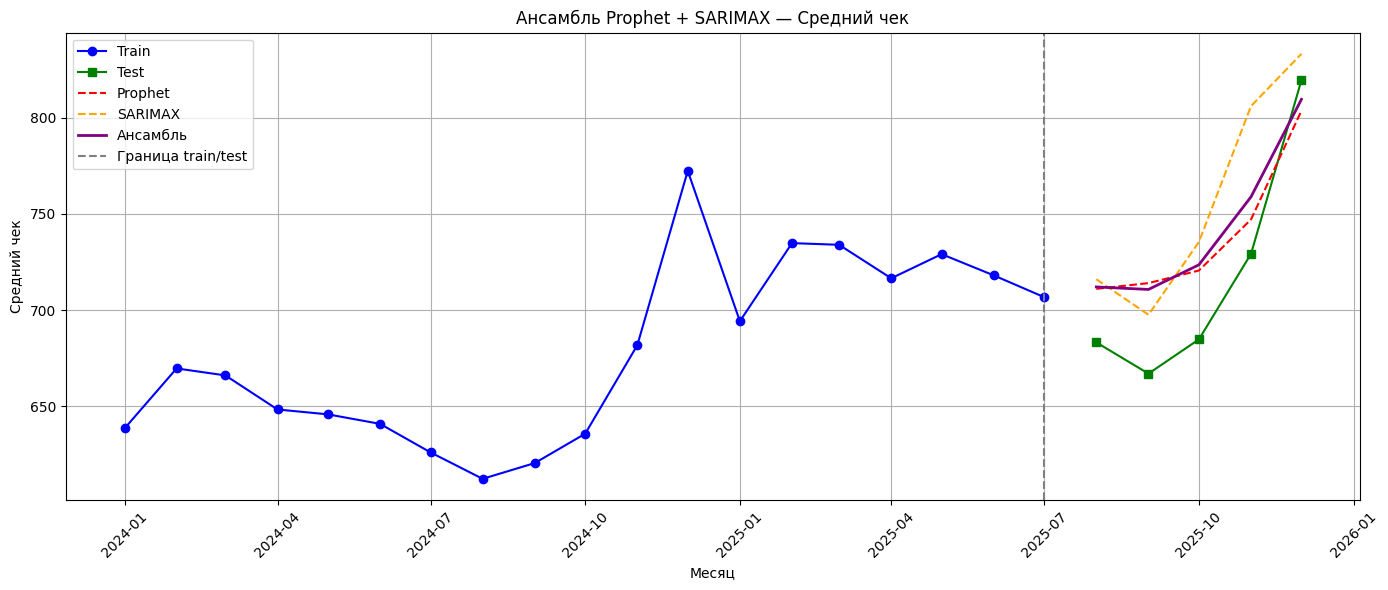


### Строим прогноз на год

Сошлась ли модель SARIMAX?: True


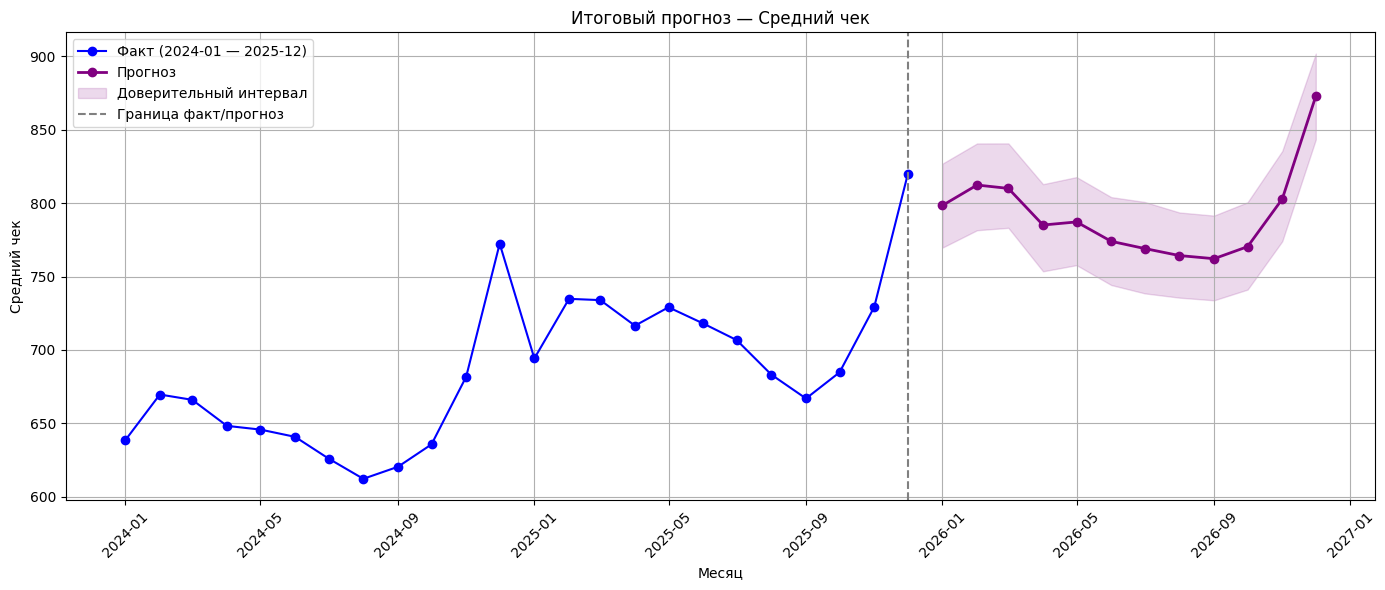


# ----------- ЧЕКИ -----------
Размер train: 19
Размер test: 5

### Prophet
Лучшие параметры Prophet: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0}

### SARIMAX
Лучшие параметры SARIMAX: {'order': (3, 0, 0), 'seasonal_order': (0, 1, 0, 12), 'trend': 'c', 'aic': np.float64(-72.80010231973303)}
Сошлась ли модель SARIMAX?: False

### Ансамбль
Лучший вес Prophet: 0.2
Лучший вес SARIMAX: 0.8
Метрики на тесте:
prophet {'mae': 2537.4578686852765, 'rmse': np.float64(3530.3341566677764), 'mape': np.float64(2.5523886822964115)}
sarimax {'mae': 1850.8083790650562, 'rmse': np.float64(1961.8370026610728), 'mape': np.float64(1.9540835354303645)}
ensemble {'mae': 1988.1382769890974, 'rmse': np.float64(2066.4114119636406), 'mape': np.float64(2.073744564803571)}


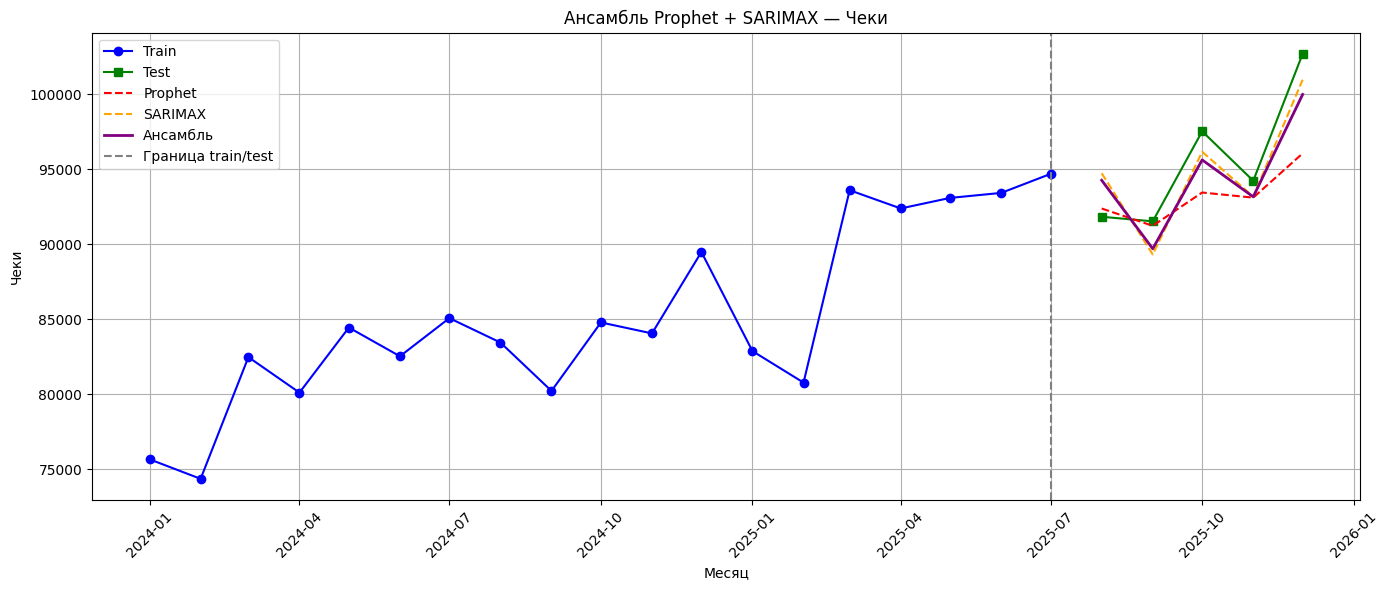


### Строим прогноз на год

Сошлась ли модель SARIMAX?: True


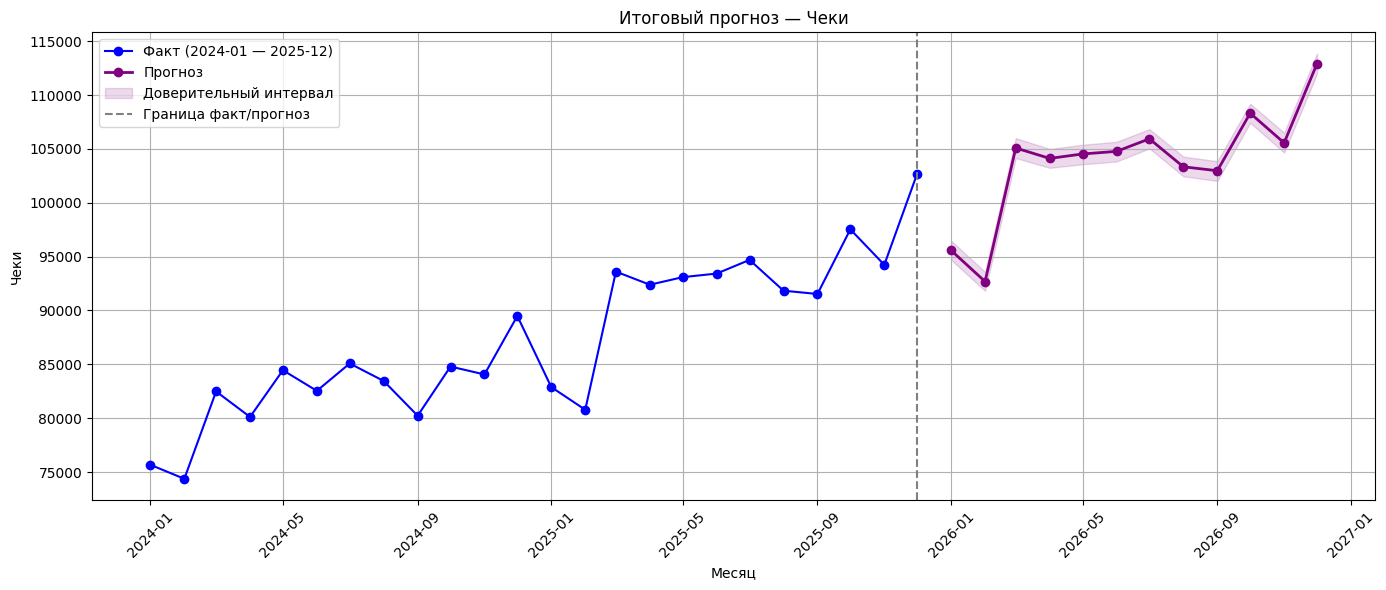

In [37]:
for metric_name, settings in metric_settings.items():
    print(f"\n# ----------- {settings['display_name'].upper()} -----------")

    # =========================
    # Подготовка данных
    # =========================
    prophet_df, sarimax_df = prepare_metric_data(
        df=df,
        season=season,
        metric_column=metric_name,
        seasonality_column=settings["seasonality_column"],
    )

    split_idx = max(int(len(prophet_df) * 0.8), 12)

    train_df = prophet_df.iloc[:split_idx].copy()
    test_df = prophet_df.iloc[split_idx:].copy()

    train_sarimax = sarimax_df.iloc[:split_idx][metric_name].dropna()
    full_sarimax_series = sarimax_df[metric_name].dropna()

    print("Размер train:", len(train_df))
    print("Размер test:", len(test_df))

    # =========================
    # Prophet
    # =========================
    print("\n### Prophet")

    best_prophet_params = tune_prophet_params(
        prophet_df=train_df,
        seasonality_column=settings["seasonality_column"],
        changepoint_scales=settings["prophet_changepoint_scales"],
        seasonality_scales=settings["prophet_seasonality_scales"],
    )

    print("Лучшие параметры Prophet:", best_prophet_params)

    model_prophet = fit_prophet_model(
        train_df=train_df,
        seasonality_column=settings["seasonality_column"],
        changepoint_prior_scale=best_prophet_params["changepoint_prior_scale"],
        seasonality_prior_scale=best_prophet_params["seasonality_prior_scale"],
    )

    forecast_prophet_test = model_prophet.predict(test_df[["ds", settings["seasonality_column"]]])
    yhat_prophet = forecast_prophet_test["yhat"].values

    # =========================
    # SARIMAX
    # =========================
    print("\n### SARIMAX")

    # Для коротких рядов уменьшаем пространство поиска
    if len(train_sarimax) < 18:
        sarimax_p = [0, 1]
        sarimax_d = [0, 1]
        sarimax_q = [0, 1]
        sarimax_P = [0, 1]
        sarimax_D = [0, 1]
        sarimax_Q = [0, 1]
        sarimax_trend = ["n", "c"]
        print("Короткий ряд: используем упрощённый поиск SARIMAX")
    else:
        sarimax_p = settings["sarimax_p"]
        sarimax_d = settings["sarimax_d"]
        sarimax_q = settings["sarimax_q"]
        sarimax_P = settings["sarimax_P"]
        sarimax_D = settings["sarimax_D"]
        sarimax_Q = settings["sarimax_Q"]
        sarimax_trend = settings["sarimax_trend"]

    best_sarimax_params = tune_sarimax_params(
        train_series=train_sarimax,
        p_values=sarimax_p,
        d_values=sarimax_d,
        q_values=sarimax_q,
        P_values=sarimax_P,
        D_values=sarimax_D,
        Q_values=sarimax_Q,
        trend_values=sarimax_trend,
    )

    print("Лучшие параметры SARIMAX:", best_sarimax_params)

    results_sarimax = fit_sarimax_model(train_sarimax, best_sarimax_params)
    print("Сошлась ли модель SARIMAX?:", results_sarimax.mle_retvals.get("converged", "unknown"))

    yhat_sarimax = results_sarimax.get_forecast(steps=len(test_df)).predicted_mean.values

    # =========================
    # Ансамбль
    # =========================
    print("\n### Ансамбль")

    y_test = test_df["y"].values

    w_prophet = select_best_ensemble_weight(
        y_true=y_test,
        yhat_prophet=yhat_prophet,
        yhat_sarimax=yhat_sarimax,
        candidate_weights=settings["ensemble_weights"],
    )
    w_sarimax = 1 - w_prophet

    print("Лучший вес Prophet:", round(w_prophet, 2))
    print("Лучший вес SARIMAX:", round(w_sarimax, 2))

    yhat_ensemble = w_prophet * yhat_prophet + w_sarimax * yhat_sarimax

    metrics_summary = {
        "prophet": calculate_metrics(y_test, yhat_prophet),
        "sarimax": calculate_metrics(y_test, yhat_sarimax),
        "ensemble": calculate_metrics(y_test, yhat_ensemble),
    }

    print("Метрики на тесте:")
    for model_name, metric_values in metrics_summary.items():
        print(model_name, metric_values)

    # =========================
    # График на тестовой выборке
    # =========================
    plt.figure(figsize=(14, 6))
    plt.plot(train_df["ds"], train_df["y"], label="Train", marker="o", color="blue")
    plt.plot(test_df["ds"], test_df["y"], label="Test", marker="s", color="green")
    plt.plot(test_df["ds"], yhat_prophet, label="Prophet", color="red", linestyle="--")
    plt.plot(test_df["ds"], yhat_sarimax, label="SARIMAX", color="orange", linestyle="--")
    plt.plot(test_df["ds"], yhat_ensemble, label="Ансамбль", color="purple", linewidth=2)
    plt.axvline(x=train_df["ds"].iloc[-1], color="gray", linestyle="--", label="Граница train/test")
    plt.title(f"Ансамбль Prophet + SARIMAX — {settings['display_name']}")
    plt.xlabel("Месяц")
    plt.ylabel(settings["display_name"])
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # =========================
    # Строим прогноз на год
    # =========================
    print("\n### Строим прогноз на год")

    # Prophet на всех данных
    model_prophet_full = fit_prophet_model(
        train_df=prophet_df,
        seasonality_column=settings["seasonality_column"],
        changepoint_prior_scale=best_prophet_params["changepoint_prior_scale"],
        seasonality_prior_scale=best_prophet_params["seasonality_prior_scale"],
    )

    # SARIMAX на всех данных
    results_sarimax_full = fit_sarimax_model(full_sarimax_series, best_sarimax_params)
    print("\nСошлась ли модель SARIMAX?:", results_sarimax_full.mle_retvals.get("converged", "unknown"))

    # Прогноз
    last_observed_month = df["month"].max()
    # Задаем месяц, с которого будем строить прогноз (максимальный месяц в исходных данных + 1 месяц вперед)
    forecast_start = last_observed_month + pd.offsets.MonthBegin(1)
    # Длительность периода, по умолчанию прогноз строим на год
    forecast_horizon_months = 12

    future_months = pd.date_range(
        start=forecast_start,
        periods=forecast_horizon_months,
        freq="MS" )

    future_df = pd.DataFrame({"ds": future_months})

    future_df = future_df.merge(
        season[["month_num", settings["seasonality_column"]]],
        left_on=future_df["ds"].dt.month,
        right_on="month_num",
        how="left",
    ).drop(columns=["month_num"])

    future_forecast_prophet = model_prophet_full.predict(future_df)
    future_forecast_sarimax = results_sarimax_full.get_forecast(steps=len(future_df)).predicted_mean.values

    future_forecast_ensemble = (
        w_prophet * future_forecast_prophet["yhat"].values
        + w_sarimax * future_forecast_sarimax
    )

    future_lower = (
        w_prophet * future_forecast_prophet["yhat_lower"].values
        + w_sarimax * future_forecast_sarimax
    )
    future_upper = (
        w_prophet * future_forecast_prophet["yhat_upper"].values
        + w_sarimax * future_forecast_sarimax
    )

    future_forecast_ensemble = np.clip(future_forecast_ensemble, settings["clip_lower"], None)
    future_lower = np.clip(future_lower, settings["clip_lower"], None)
    future_upper = np.clip(future_upper, settings["clip_lower"], None)

    forecast_2026 = pd.DataFrame(
        {
            "month": future_months.strftime("%Y-%m"),
            f"forecast_{metric_name}": future_forecast_ensemble,
            f"lower_bound_{metric_name}": future_lower,
            f"upper_bound_{metric_name}": future_upper,
            f"prophet_{metric_name}": future_forecast_prophet["yhat"].values,
            f"sarimax_{metric_name}": future_forecast_sarimax,
        }
    )

    round_columns = [
        f"forecast_{metric_name}",
        f"lower_bound_{metric_name}",
        f"upper_bound_{metric_name}",
        f"prophet_{metric_name}",
        f"sarimax_{metric_name}",
    ]

    if settings["round_digits"] == 0:
        forecast_2026[round_columns] = forecast_2026[round_columns].round().astype(int)
    else:
        forecast_2026[round_columns] = forecast_2026[round_columns].round(settings["round_digits"])

    forecast_end = future_months.max()
    history_start = df["month"].min()
    history_end = df["month"].max()

    # =========================
    # График прогноза
    # =========================
    plt.figure(figsize=(14, 6))
    plt.plot(df["month"],
             df[metric_name],
             label=f"Факт ({history_start.strftime('%Y-%m')} — {history_end.strftime('%Y-%m')})",
             marker="o",
             color="blue")
    plt.plot(future_months, forecast_2026[f"forecast_{metric_name}"], label="Прогноз", marker="o", color="purple", linewidth=2)
    plt.fill_between(
        future_months,
        forecast_2026[f"lower_bound_{metric_name}"],
        forecast_2026[f"upper_bound_{metric_name}"],
        color="purple",
        alpha=0.15,
        label="Доверительный интервал",
    )
    plt.axvline(x=df["month"].iloc[-1], color="gray", linestyle="--", label="Граница факт/прогноз")
    plt.title(f"Итоговый прогноз — {settings['display_name']}")
    plt.xlabel("Месяц")
    plt.ylabel(settings["display_name"])
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    all_metric_results[metric_name] = {
        "best_prophet_params": best_prophet_params,
        "best_sarimax_params": best_sarimax_params,
        "w_prophet": w_prophet,
        "w_sarimax": w_sarimax,
        "test_metrics": metrics_summary,
    }

    forecast_tables_2026[metric_name] = forecast_2026

In [39]:
forecast_2026_combined = forecast_tables_2026["clients"][
    ["month", "forecast_clients", "lower_bound_clients", "upper_bound_clients"]
].merge(
    forecast_tables_2026["avg_check"][
        ["month", "forecast_avg_check", "lower_bound_avg_check", "upper_bound_avg_check"]
    ],
    on="month",
    how="left",
).merge(
    forecast_tables_2026["transactions"][
        ["month", "forecast_transactions", "lower_bound_transactions", "upper_bound_transactions"]
    ],
    on="month",
    how="left",
)

In [40]:
forecast_2026_combined["forecast_revenue"] = (
    forecast_2026_combined["forecast_avg_check"] * forecast_2026_combined["forecast_transactions"]
).round().astype(int)

forecast_2026_combined["lower_bound_revenue"] = (
    forecast_2026_combined["lower_bound_avg_check"] * forecast_2026_combined["lower_bound_transactions"]
).round().astype(int)

forecast_2026_combined["upper_bound_revenue"] = (
    forecast_2026_combined["upper_bound_avg_check"] * forecast_2026_combined["upper_bound_transactions"]
).round().astype(int)

In [41]:
forecast_2026_combined["forecast_frequency"] = (
    forecast_2026_combined["forecast_transactions"] / forecast_2026_combined["forecast_clients"]
).replace([np.inf, -np.inf], np.nan).round(2)

forecast_2026_combined["lower_bound_frequency"] = (
    forecast_2026_combined["lower_bound_transactions"] / forecast_2026_combined["lower_bound_clients"]
).replace([np.inf, -np.inf], np.nan).round(2)

forecast_2026_combined["upper_bound_frequency"] = (
    forecast_2026_combined["upper_bound_transactions"] / forecast_2026_combined["upper_bound_clients"]
).replace([np.inf, -np.inf], np.nan).round(2)

In [42]:
forecast_2026_combined = forecast_2026_combined[
    [
        "month",
        "forecast_clients",
        "forecast_transactions",
        "forecast_revenue",
        "forecast_avg_check",
        "forecast_frequency",
        "lower_bound_clients",
        "lower_bound_transactions",
        "lower_bound_revenue",
        "lower_bound_avg_check",
        "lower_bound_frequency",
        "upper_bound_clients",
        "upper_bound_transactions",
        "upper_bound_revenue",
        "upper_bound_avg_check",
        "upper_bound_frequency",
    ]
]

In [43]:
print("\n📊 Итоговый прогноз:\n")
forecast_2026_combined


📊 Итоговый прогноз:



,month,forecast_clients,forecast_transactions,forecast_revenue,forecast_avg_check,forecast_frequency,lower_bound_clients,lower_bound_transactions,lower_bound_revenue,lower_bound_avg_check,lower_bound_frequency,upper_bound_clients,upper_bound_transactions,upper_bound_revenue,upper_bound_avg_check,upper_bound_frequency
0,2026-01,24142,95573,76300705,798.35,3.96,24041,94695,72881060,769.64,3.94,24241,96481,79768561,826.78,3.98
1,2026-02,24097,92685,75283391,812.25,3.85,24004,91823,71758756,781.49,3.83,24205,93575,78653530,840.54,3.87
2,2026-03,25697,105082,85112217,809.96,4.09,25591,104147,81560640,783.13,4.07,25808,106001,89101261,840.57,4.11
3,2026-04,25394,104115,81733398,785.03,4.10,25278,103242,77796977,753.54,4.08,25514,104997,85344712,812.83,4.12
4,2026-05,25638,104529,82278957,787.14,4.08,25496,103572,78480647,757.74,4.06,25778,105383,86165356,817.64,4.09
5,2026-06,25564,104767,81083372,773.94,4.10,25411,103828,77269836,744.21,4.09,25723,105661,84953557,804.02,4.11
6,2026-07,25605,105933,81465655,769.03,4.14,25410,105043,77576356,738.52,4.13,25804,106829,85540117,800.72,4.14
7,2026-08,25189,103338,78977100,764.26,4.10,24948,102456,75368683,735.62,4.11,25414,104284,82756654,793.57,4.10
8,2026-09,24739,102972,78477021,762.12,4.16,24465,102024,74866231,733.81,4.17,25017,103856,82195793,791.44,4.15
9,2026-10,25207,108313,83435670,770.32,4.30,24923,107423,79612260,741.11,4.31,25513,109195,87414965,800.54,4.28


In [44]:
forecast_2026_combined.to_excel("Прогноз.xlsx", index=False)
print("✅ Прогноз сохранён в файл 'Прогноз.xlsx'")

✅ Прогноз сохранён в файл 'Прогноз.xlsx'
